# 17.6 Denoising Autoencoders

##### Data

2023-07-28 05:29:15.714499: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


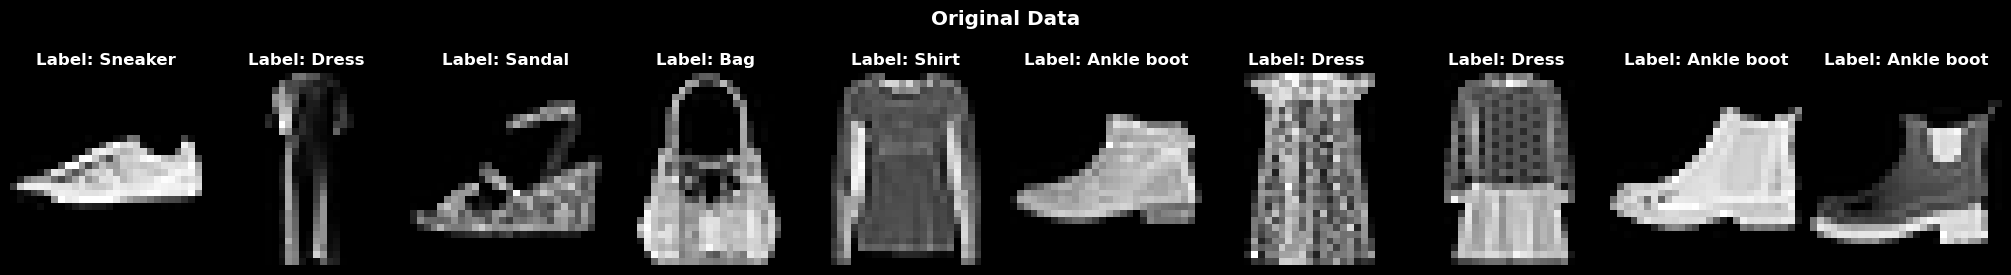

In [1]:
import load_fashion_mnist

(
    (x_train_norm, y_train),
    (x_valid_norm, y_valid),
    (x_test_norm, y_test),
) = load_fashion_mnist.load_data()

##### Model

In [2]:
import tensorflow as tf

encoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
        tf.keras.layers.Dense(
            30,
            activation="selu",
            kernel_initializer="lecun_normal",
        ),
    ]
)
decoder = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            100,
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(30,),
        ),
        tf.keras.layers.Dense(
            28 * 28,
            activation="sigmoid",
        ),
        tf.keras.layers.Reshape((28, 28)),
    ]
)
dropout_ae = tf.keras.models.Sequential([encoder, decoder])

dropout_ae.compile(optimizer="adam", loss="binary_crossentropy")
dropout_ae.summary()

cb_early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)
history = dropout_ae.fit(
    x_train_norm,
    x_train_norm,
    epochs=20,
    validation_data=[x_valid_norm, x_valid_norm],
    callbacks=[cb_early_stopping],
)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 30)                81530     
                                                                 
 sequential_1 (Sequential)   (None, 28, 28)            82284     
                                                                 
Total params: 163,814
Trainable params: 163,814
Non-trainable params: 0
_________________________________________________________________


2023-07-28 05:29:19.624009: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-28 05:29:19.730469: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-28 05:29:19.730669: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-28 05:29:19.731337: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Epoch 1/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3195 - val_loss: 0.2970
Epoch 2/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2992 - val_loss: 0.2912
Epoch 3/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2954 - val_loss: 0.2885
Epoch 4/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2934 - val_loss: 0.2867
Epoch 5/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2920 - val_loss: 0.2855
Epoch 6/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2909 - val_loss: 0.2852
Epoch 7/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2902 - val_loss: 0.2843
Epoch 8/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.2895 - val_loss: 0.2838
Epoch 9/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.2890 - val_loss: 0.2830
Epoch 10/20
1500/1500 [==============================] - 3s 2ms/step - loss: 0.288

##### Evaluation

313/313 [==============================] - 1s 1ms/step


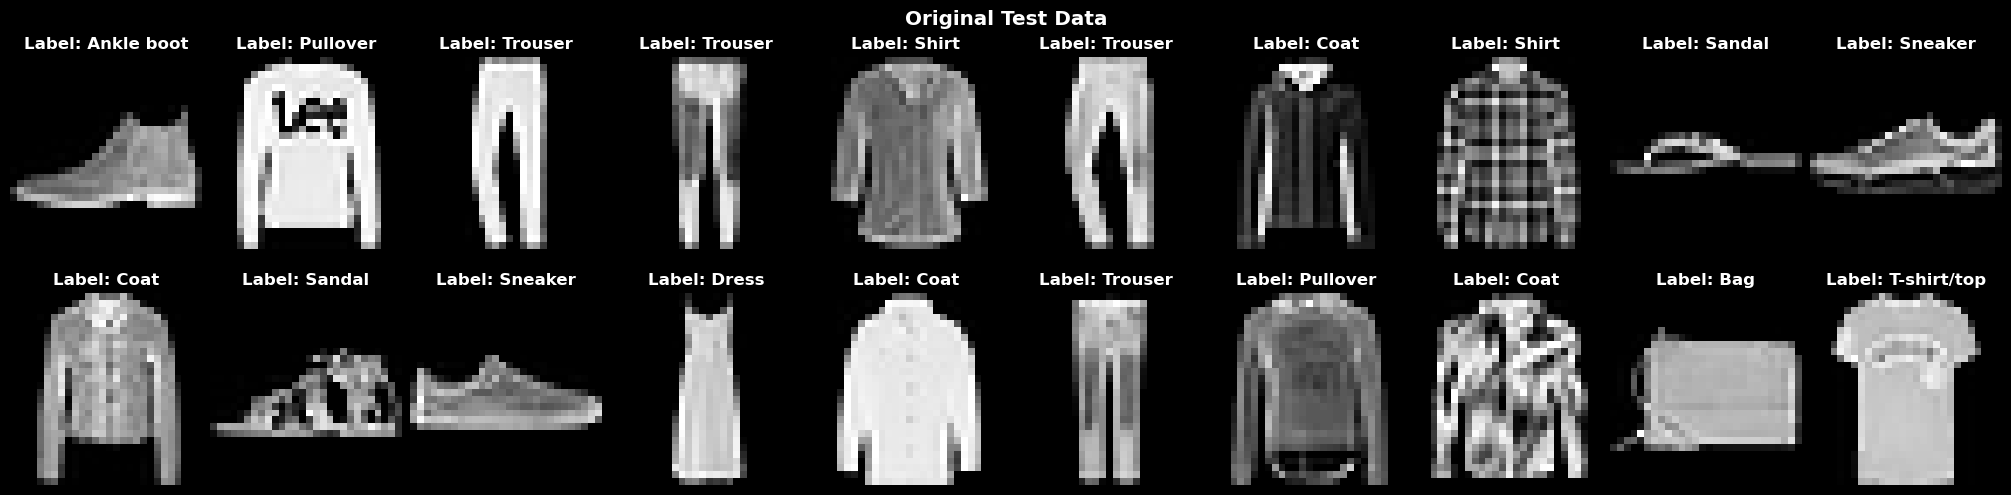

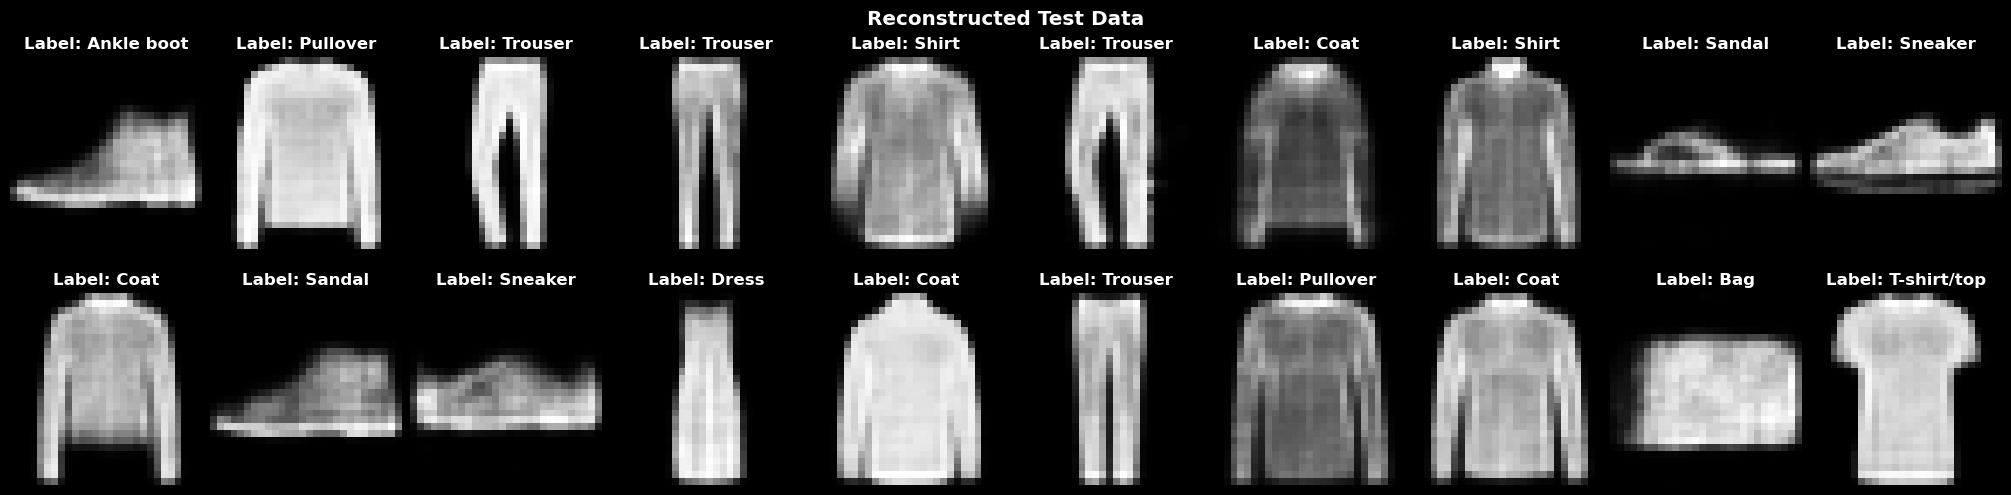

In [3]:
import evaluation

ev = evaluation.Evaluation(
    model=dropout_ae,
    x_test=x_test_norm,
    y_test=y_test,
)
ev.reconstruction_test()

313/313 [==============================] - 1s 1ms/step


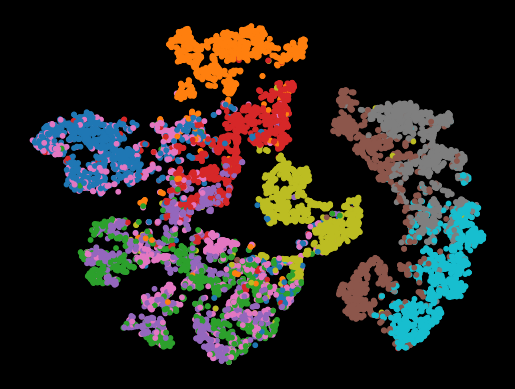

In [4]:
ev.dl_plot()

##### Evaluation with Dropout Images

313/313 [==============================] - 0s 1ms/step


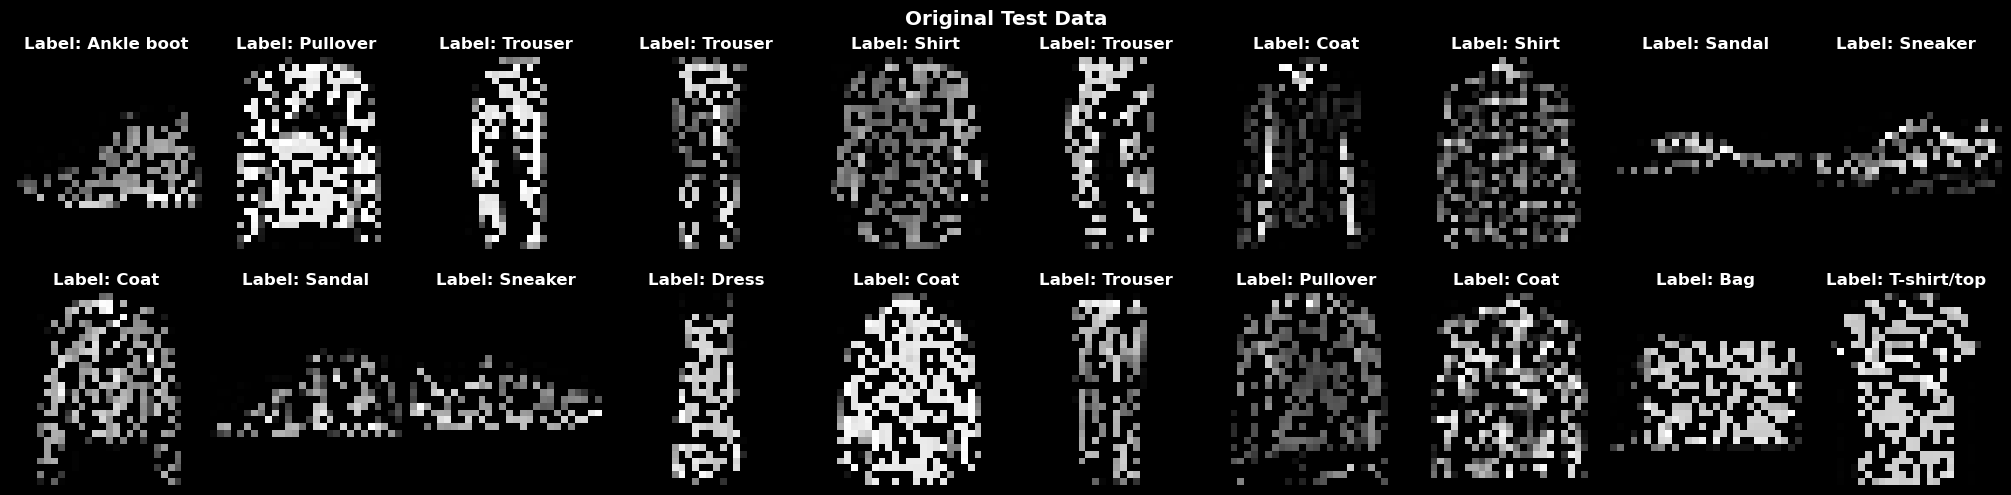

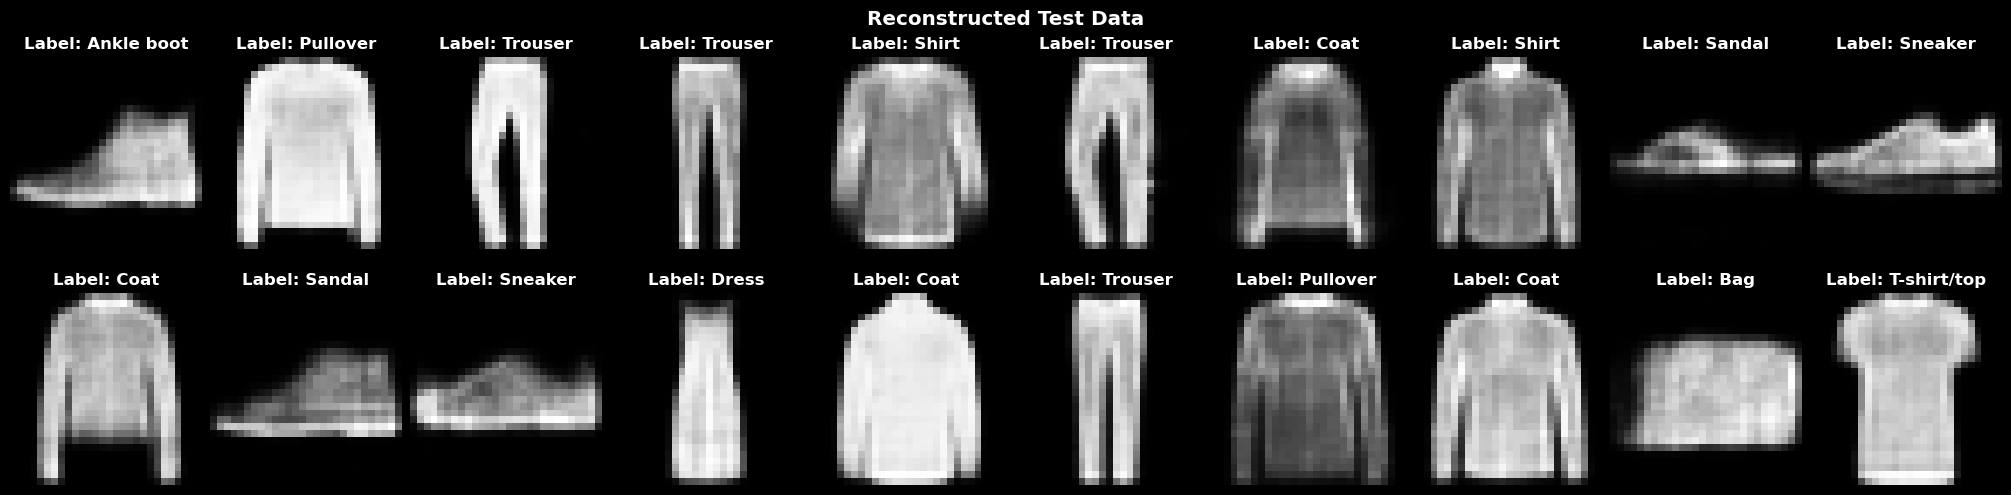

In [9]:
dropout = tf.keras.layers.Dropout(0.5)
x_test_norm_dropout = dropout(x_test_norm, training=True)

ev = evaluation.Evaluation(
    model=dropout_ae,
    x_test=x_test_norm_dropout,
    y_test=y_test,
)
ev.reconstruction_test()